<a href="https://colab.research.google.com/github/SweetlinN/Employee_Promotion/blob/main/Employee_Promotion_Predict.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# problem statement = Employee Promotion Prediction

# 1.import libraries

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,precision_score,f1_score,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

# 2.Data Gathering

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving employee_promotion_dataset_filled.csv to employee_promotion_dataset_filled.csv


In [ ]:
df = pd.read_csv('employee_promotion_dataset_filled.csv')

In [ ]:
# first five rows of the dataset

In [ ]:
df.head()

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,...,education_level,job_role,department,city,company_type,work_mode,marital_status,has_certifications,promotion,job_satisfaction
0,56.0,7250.0,16.0,46.0,4.11,15.0,7.0,29.1,160.0,15.0,...,Master,Data Scientist,Finance,Tanta,Startup,Onsite,Married,0.0,0,NaN
1,46.0,18372.0,9.0,41.0,2.60,29.0,19.0,NaN,58.0,9.0,...,Bachelor,NaN,Operations,Tanta,SME,Remote,Married,0.0,0,Medium
2,32.0,20279.0,11.0,37.0,3.66,33.0,21.0,26.0,67.0,28.0,...,Master,Data Scientist,Operations,Mansoura,SME,Onsite,Married,0.0,0,High
3,60.0,33193.0,18.0,24.0,2.58,4.0,27.0,18.8,48.0,13.0,...,High School,HR,Operations,Alexandria,Enterprise,Remote,Single,1.0,0,Medium
4,NaN,29868.0,39.0,NaN,3.29,NaN,NaN,4.4,14.0,13.0,...,PhD,HR,Operations,Mansoura,Startup,Hybrid,Married,1.0,0,Low


In [ ]:
# last five rows of the dataset

In [ ]:
df.tail()

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,...,education_level,job_role,department,city,company_type,work_mode,marital_status,has_certifications,promotion,job_satisfaction
14995,48.0,5498.0,12.0,49.0,1.83,39.0,26.0,21.4,41.0,8.0,...,High School,HR,IT,Cairo,Startup,Remote,Married,0.0,0,Medium
14996,26.0,28483.0,21.0,44.0,NaN,27.0,21.0,NaN,85.0,16.0,...,PhD,HR,HR,Mansoura,Startup,Remote,Single,1.0,0,High
14997,37.0,8728.0,25.0,57.0,3.87,22.0,27.0,25.5,165.0,24.0,...,Bachelor,HR,Operations,Alexandria,Startup,Remote,Married,1.0,1,High
14998,27.0,21877.0,NaN,51.0,1.31,6.0,5.0,32.9,0.0,16.0,...,PhD,Data Scientist,IT,Aswan,SME,Onsite,Single,1.0,0,High
14999,54.0,29703.0,28.0,31.0,3.85,38.0,5.0,46.1,27.0,14.0,...,High School,HR,Finance,Aswan,SME,Hybrid,Married,1.0,1,High


# 3.(EDA) Exploratory Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     13822 non-null  float64
 1   salary                  13747 non-null  float64
 2   experience_years        13824 non-null  float64
 3   working_hours_per_week  13795 non-null  float64
 4   performance_score       13817 non-null  float64
 5   projects_completed      13769 non-null  float64
 6   overtime_hours          13804 non-null  float64
 7   distance_from_home_km   13770 non-null  float64
 8   training_hours          13758 non-null  float64
 9   absent_days             13772 non-null  float64
 10  gender                  13816 non-null  object 
 11  education_level         13820 non-null  object 
 12  job_role                13772 non-null  object 
 13  department              13811 non-null  object 
 14  city                    13817 non-null

In [ ]:
df.shape

(15000, 21)

In [ ]:
# check null values

In [ ]:
df.isnull().sum()

,0
age,1178
salary,1253
experience_years,1176
working_hours_per_week,1205
performance_score,1183
projects_completed,1231
overtime_hours,1196
distance_from_home_km,1230
training_hours,1242
absent_days,1228


In [ ]:
df.columns

Index(['age', 'salary', 'experience_years', 'working_hours_per_week',
       'performance_score', 'projects_completed', 'overtime_hours',
       'distance_from_home_km', 'training_hours', 'absent_days', 'gender',
       'education_level', 'job_role', 'department', 'city', 'company_type',
       'work_mode', 'marital_status', 'has_certifications', 'promotion',
       'job_satisfaction'],
      dtype='object')

In [ ]:
#  categorical columns = 'gender','education_level', 'job_role', 'department', 'city', 'company_type','work_mode', 'marital_status',
                          # job_satisfaction

In [ ]:
# null values imputations

In [ ]:

df['gender'].fillna(df['gender'].mode()[0],inplace=True)
df['education_level'].fillna(df['education_level'].mode()[0],inplace=True)
df['job_role'].fillna(df['job_role'].mode()[0],inplace=True)
df['department'].fillna(df['department'].mode()[0],inplace=True)
df['city'].fillna(df['city'].mode()[0],inplace=True)
df['company_type'].fillna(df['company_type'].mode()[0],inplace=True)
df['work_mode'].fillna(df['work_mode'].mode()[0],inplace=True)
df['marital_status'].fillna(df['marital_status'].mode()[0],inplace=True)
df['job_satisfaction'].fillna(df['job_satisfaction'].mode()[0],inplace=True)


In [ ]:
# numerical columns = age,salary,experience_years,workings_hours_per_week,performance_score,project_completed,
                        # overtime_hours,distance_from_home_km,training_hours,absent_days,has_certifications.

In [ ]:
cols = [
    'age','salary', 'experience_years', 'working_hours_per_week',
    'performance_score', 'projects_completed', 'overtime_hours',
    'distance_from_home_km', 'training_hours', 'absent_days',
    'has_certifications'
]

for col in cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.isnull().sum()

,0
age,0
salary,0
experience_years,0
working_hours_per_week,0
performance_score,0
projects_completed,0
overtime_hours,0
distance_from_home_km,0
training_hours,0
absent_days,0


In [ ]:
# check unique values

In [ ]:
df['gender'].value_counts()

,count
gender,
Female,8095
Male,6905


In [ ]:
df['education_level'].value_counts()

,count
education_level,
PhD,4693
High School,3462
Bachelor,3429
Master,3416


In [ ]:
df['job_role'].value_counts()

,count
job_role,
Engineer,3590
Data Scientist,2319
HR,2298
Designer,2289
Manager,2276
Sales,2228


In [ ]:
df['department'].value_counts()

,count
department,
Operations,3542
HR,2346
Marketing,2314
IT,2271
AI,2269
Finance,2258


In [ ]:
df['city'].value_counts()

,count
city,
Alexandria,3603
Aswan,2370
Mansoura,2319
Tanta,2280
Giza,2235
Cairo,2193


In [ ]:
df['company_type'].value_counts()

,count
company_type,
Startup,5875
SME,4572
Enterprise,4553


In [ ]:
df['work_mode'].value_counts()

,count
work_mode,
Hybrid,5847
Remote,4601
Onsite,4552


In [ ]:
df['marital_status'].value_counts()

,count
marital_status,
Married,8109
Single,6891


In [ ]:
df['job_satisfaction'].value_counts()

,count
job_satisfaction,
Medium,5855
Low,4589
High,4556


# 4. feature creation

In [ ]:
# categorical to numerical columns

In [ ]:

catecategoricalgorical_cols = ['job_satisfaction','marital_status','work_mode','company_type',
                    'city','department','job_role','education_level','gender']

In [ ]:
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder()

df[categorical_cols] = encoder.fit_transform(df[categorical_cols])

In [ ]:
df.head()

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,...,education_level,job_role,department,city,company_type,work_mode,marital_status,has_certifications,promotion,job_satisfaction
0,56.0,7250.0,16.0,46.0,4.11,15.0,7.0,29.1,160.0,15.0,...,2.0,0.0,1.0,5.0,2.0,1.0,0.0,0.0,0,2.0
1,46.0,18372.0,9.0,41.0,2.60,29.0,19.0,25.6,58.0,9.0,...,0.0,2.0,5.0,5.0,1.0,2.0,0.0,0.0,0,2.0
2,32.0,20279.0,11.0,37.0,3.66,33.0,21.0,26.0,67.0,28.0,...,2.0,0.0,5.0,4.0,1.0,1.0,0.0,0.0,0,0.0
3,60.0,33193.0,18.0,24.0,2.58,4.0,27.0,18.8,48.0,13.0,...,1.0,3.0,5.0,0.0,0.0,2.0,1.0,1.0,0,2.0
4,41.0,29868.0,39.0,40.0,3.29,25.0,14.0,4.4,14.0,13.0,...,3.0,3.0,5.0,4.0,2.0,0.0,0.0,1.0,0,1.0


# 5. visualization

<Axes: xlabel='promotion', ylabel='count'>

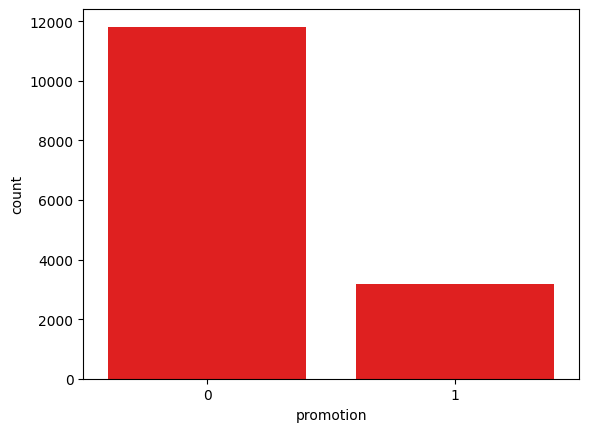

In [ ]:
import seaborn as sns
sns.countplot(x='promotion',color='red', data=df)

# 6.Split training data and testing data

In [ ]:
X=df.drop('promotion',axis=1)
y=df['promotion']

In [ ]:
X_train,y_train,X_test,y_test = train_test_split(X,y,test_size=0.2,random_state=42,
                                                 stratify=y)# very important for imbalanced data

In [ ]:
X

,age,salary,experience_years,working_hours_per_week,performance_score,projects_completed,overtime_hours,distance_from_home_km,training_hours,absent_days,gender,education_level,job_role,department,city,company_type,work_mode,marital_status,has_certifications,job_satisfaction
0,56.0,7250.0,16.0,46.0,4.11,15.0,7.0,29.1,160.0,15.0,1.0,2.0,0.0,1.0,5.0,2.0,1.0,0.0,0.0,2.0
1,46.0,18372.0,9.0,41.0,2.60,29.0,19.0,25.6,58.0,9.0,0.0,0.0,2.0,5.0,5.0,1.0,2.0,0.0,0.0,2.0
2,32.0,20279.0,11.0,37.0,3.66,33.0,21.0,26.0,67.0,28.0,0.0,2.0,0.0,5.0,4.0,1.0,1.0,0.0,0.0,0.0
3,60.0,33193.0,18.0,24.0,2.58,4.0,27.0,18.8,48.0,13.0,0.0,1.0,3.0,5.0,0.0,0.0,2.0,1.0,1.0,2.0
4,41.0,29868.0,39.0,40.0,3.29,25.0,14.0,4.4,14.0,13.0,1.0,3.0,3.0,5.0,4.0,2.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,48.0,5498.0,12.0,49.0,1.83,39.0,26.0,21.4,41.0,8.0,0.0,1.0,3.0,3.0,2.0,2.0,2.0,0.0,0.0,2.0
14996,26.0,28483.0,21.0,44.0,3.00,27.0,21.0,25.6,85.0,16.0,1.0,3.0,3.0,2.0,4.0,2.0,2.0,1.0,1.0,0.0
14997,37.0,8728.0,25.0,57.0,3.87,22.0,27.0,25.5,165.0,24.0,0.0,0.0,3.0,5.0,0.0,2.0,2.0,0.0,1.0,0.0
14998,27.0,21877.0,20.0,51.0,1.31,6.0,5.0,32.9,0.0,16.0,0.0,3.0,0.0,3.0,1.0,1.0,1.0,1.0,1.0,0.0


In [ ]:
y

,promotion
0,0
1,0
2,0
3,0
4,0
...,...
14995,0
14996,0
14997,1
14998,0


In [ ]:
df['promotion'].value_counts()

,count
promotion,
0,11814
1,3186


# 7. Train models and Predict and Evaluate

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report

# 1. Split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Resample training set
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# 3. Train model
clf = RandomForestClassifier(class_weight='balanced', random_state=42)
clf.fit(X_train_res, y_train_res)

lgr = LogisticRegression(class_weight = 'balanced',random_state=42)
lgr.fit(X_train_res,y_train_res)

XgbC = XGBClassifier(class_weight = 'balanced',random_state=42)
XgbC.fit(X_train_res,y_train_res)

# 4. Evaluate
print("=======Random Forest Classifier=======================================")
y_pred1 = clf.predict(X_test)
print(classification_report(y_test, y_pred1))
print("Accuracy: RandomForestClassifier",accuracy_score(y_test,y_pred1)*100)
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred1))

print("=======Logistic Regression============================================")
y_pred2 = lgr.predict(X_test)
print(classification_report(y_test, y_pred2))
print("Accuracy: LogisticRegression",accuracy_score(y_test,y_pred2)*100)
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred2))

print("=======XGBClassifier==================================================")
y_pred3 = XgbC.predict(X_test)
print(classification_report(y_test,y_pred3))
print("Accuracy: XGBClassifier",accuracy_score(y_test,y_pred3)*100)
print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred3))



=======Random Forest Classifier=======================================
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2363
           1       0.99      1.00      0.99       637

    accuracy                           1.00      3000
   macro avg       0.99      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000

Accuracy: RandomForestClassifier 99.7
Confusion Matrix:
 [[2356    7]
 [   2  635]]
=======Logistic Regression============================================
              precision    recall  f1-score   support

           0       0.96      0.82      0.88      2363
           1       0.56      0.87      0.68       637

    accuracy                           0.83      3000
   macro avg       0.76      0.84      0.78      3000
weighted avg       0.87      0.83      0.84      3000

Accuracy: LogisticRegression 82.66666666666667
Confusion Matrix:
 [[1926  437]
 [  83  554]]
=======XGBClassifier=======

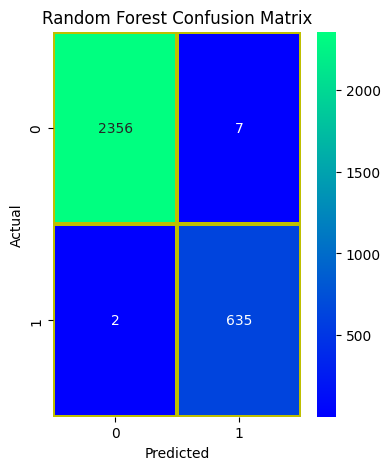

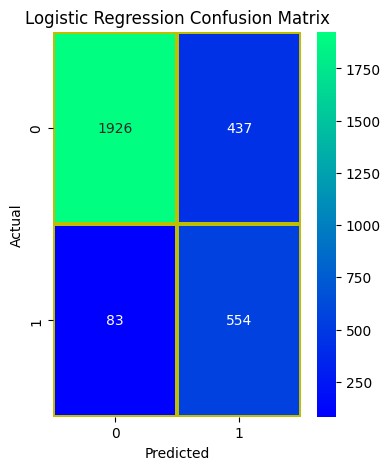

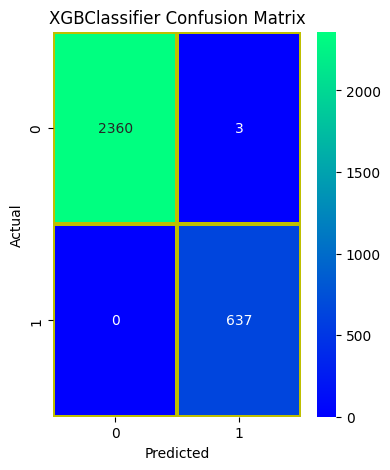

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Function to plot confusion matrix
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,5))
    sns.heatmap(cm, annot=True, fmt='d',linecolor='y',linewidths ='1.6', cmap="winter",
                xticklabels=[0,1], yticklabels=[0,1])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

# Random Forest
plot_conf_matrix(y_test, y_pred1, "Random Forest Confusion Matrix")

# Logistic Regression
plot_conf_matrix(y_test, y_pred2, "Logistic Regression Confusion Matrix")

# XGBClassifier
plot_conf_matrix(y_test, y_pred3, "XGBClassifier Confusion Matrix")
